In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [49]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [51]:
df.isna().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df['ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [54]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


<Axes: xlabel='HeartDisease', ylabel='count'>

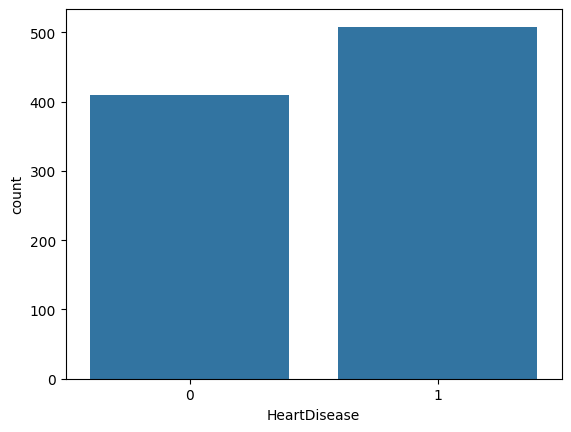

In [55]:
sns.countplot(x='HeartDisease', data=df)

<Axes: xlabel='Sex', ylabel='count'>

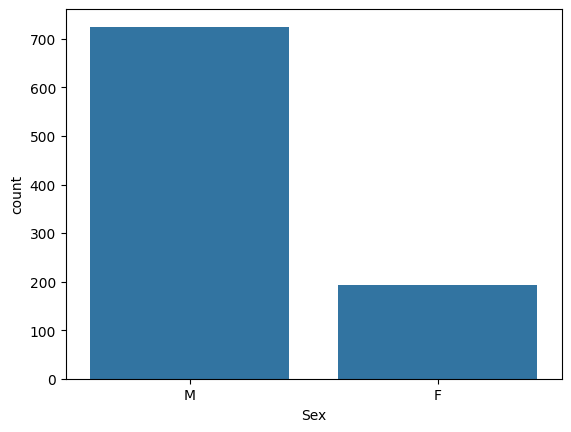

In [56]:
sns.countplot(x='Sex',data=df)

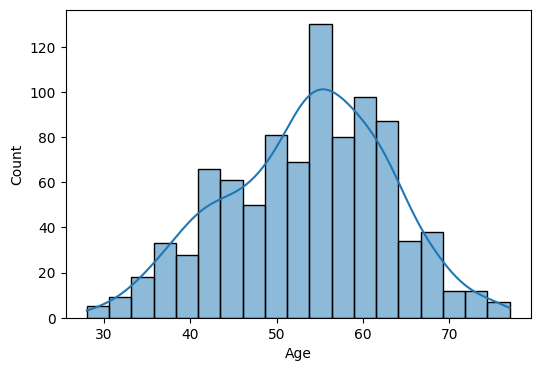

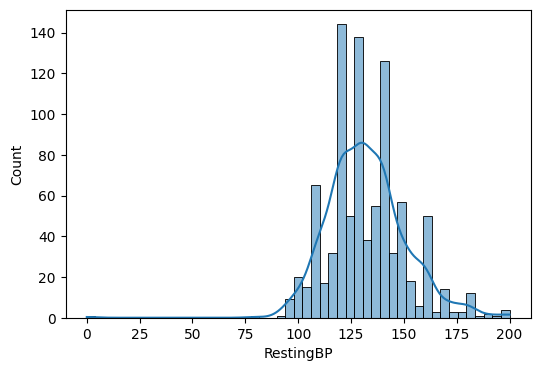

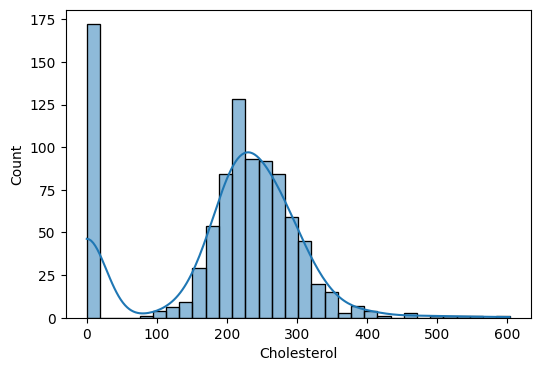

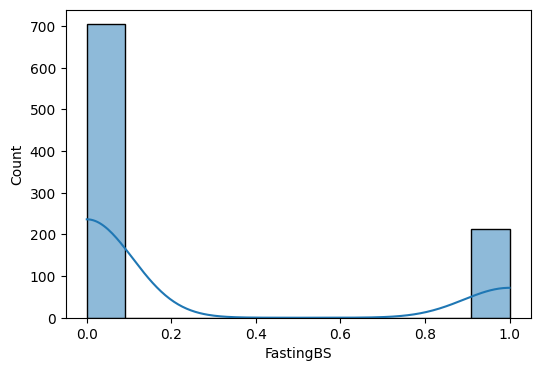

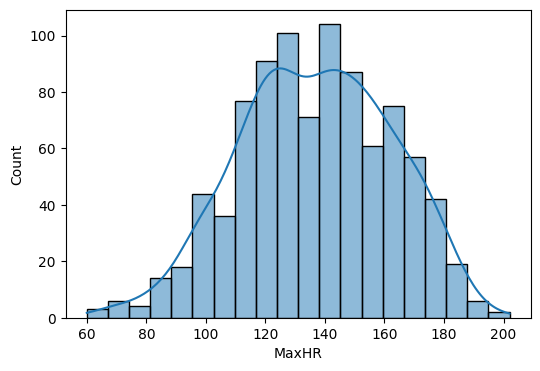

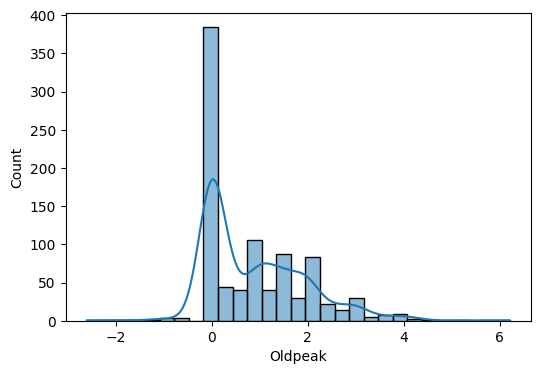

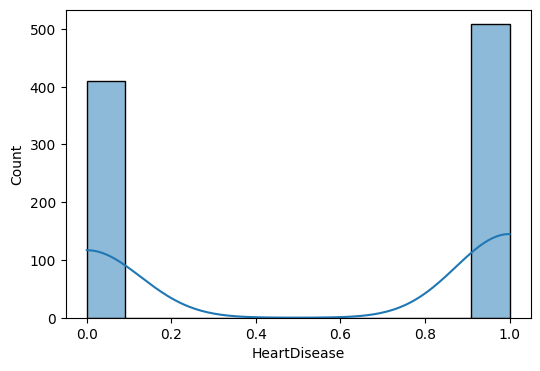

In [57]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
for cols in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(x=cols, data=df, kde=True)


<Axes: xlabel='Sex', ylabel='count'>

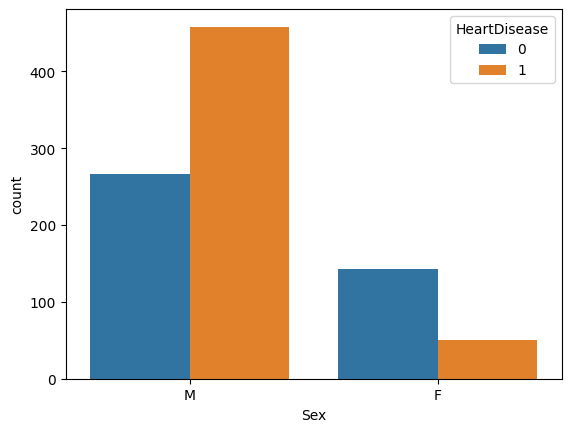

In [58]:
sns.countplot(x='Sex', hue='HeartDisease', data=df)

<Axes: xlabel='FastingBS', ylabel='count'>

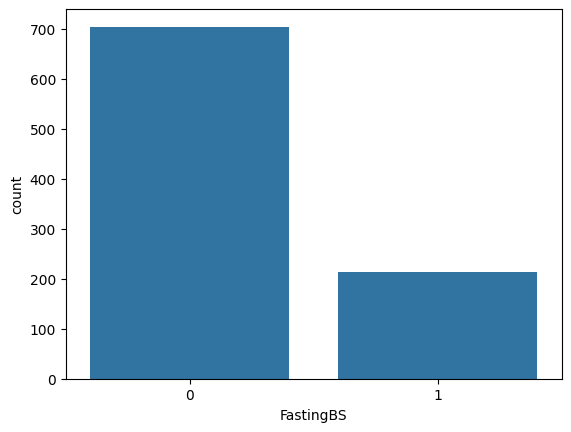

In [59]:
sns.countplot(x='FastingBS', data=df)

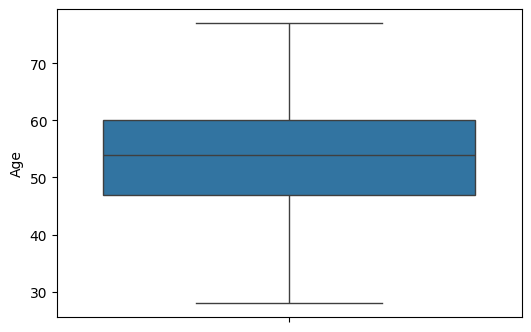

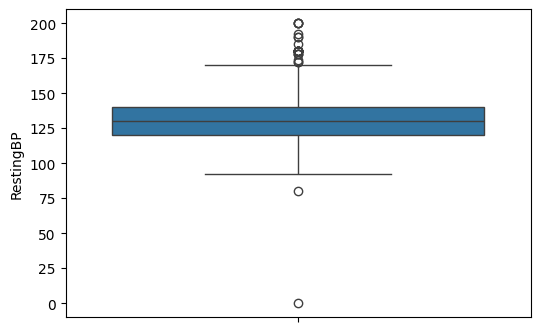

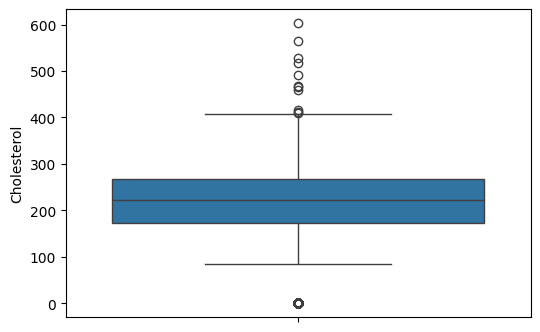

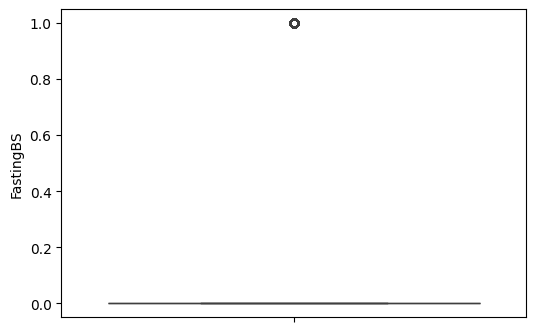

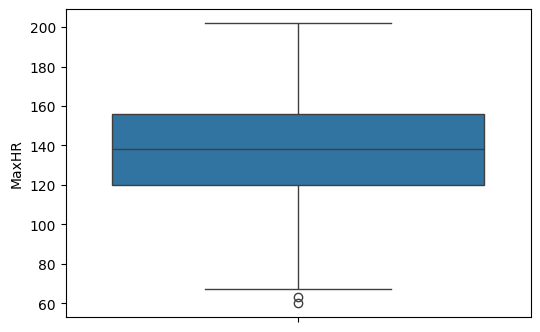

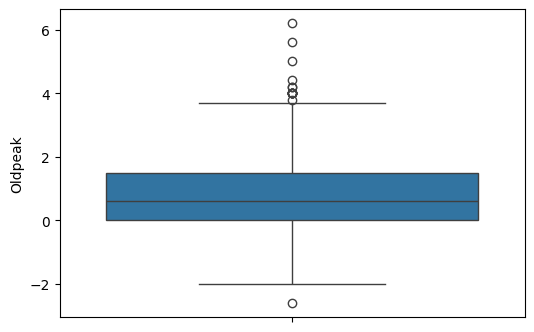

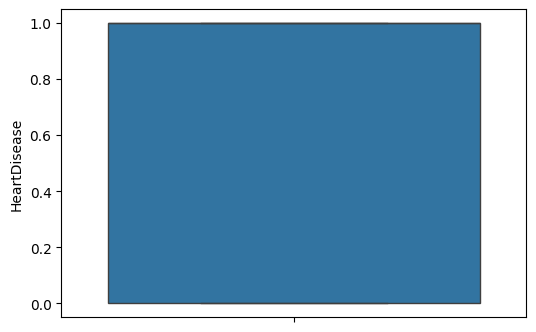

In [60]:
for cols in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(df[cols])
  plt.show()

In [61]:
df_c = df.copy()

In [62]:
df_c.duplicated().sum()

np.int64(0)

In [63]:
mean_chol = df_c.loc[df_c['Cholesterol'] != 0, 'Cholesterol'].mean()
df_c['Cholesterol'].replace(0, mean_chol, inplace=True)
df_c['Cholesterol'] = df_c['Cholesterol'].round(2)

<Axes: xlabel='Cholesterol', ylabel='Count'>

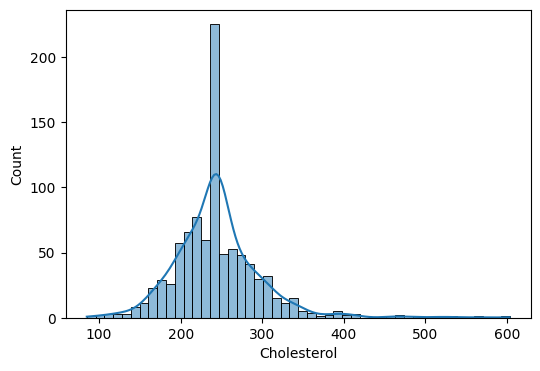

In [64]:
plt.figure(figsize=(6,4))
sns.histplot(df_c['Cholesterol'], kde=True)

In [65]:
mean_rest = df_c.loc[df_c['RestingBP'] != 0, 'RestingBP'].mean()
df_c['RestingBP'].replace(0, mean_chol, inplace=True)
df_c['RestingBP'] = df_c['RestingBP'].round(2)

<Axes: xlabel='RestingBP', ylabel='Count'>

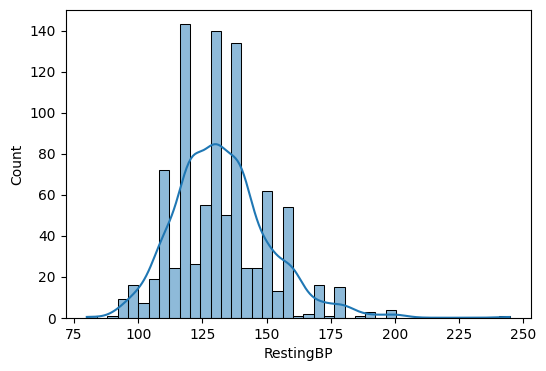

In [66]:
plt.figure(figsize=(6,4))
sns.histplot(df_c['RestingBP'], kde=True)

In [67]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<Axes: xlabel='ChestPainType', ylabel='count'>

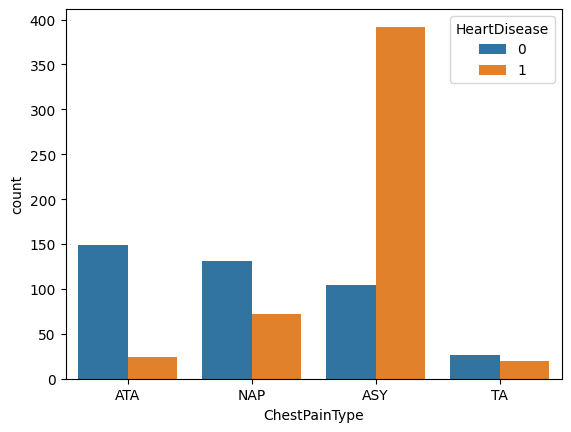

In [68]:
sns.countplot(x='ChestPainType', hue = 'HeartDisease', data=df)

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

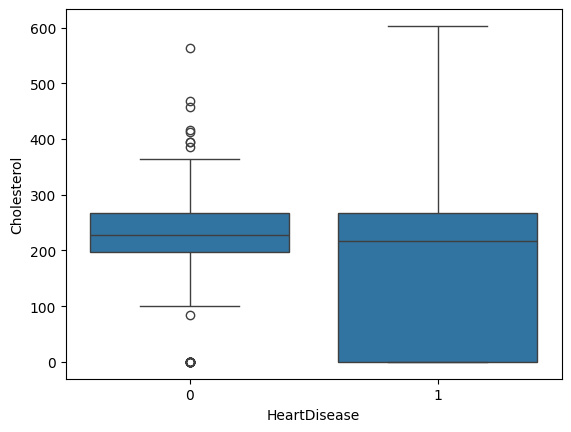

In [69]:
sns.boxplot(x='HeartDisease', y='Cholesterol', data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

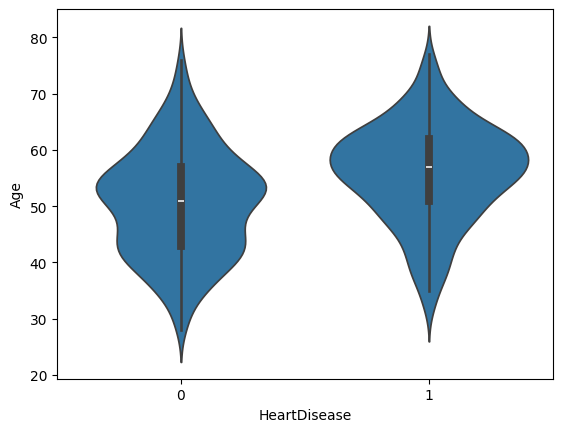

In [70]:
sns.violinplot(x='HeartDisease', y='Age', data=df)

<Axes: >

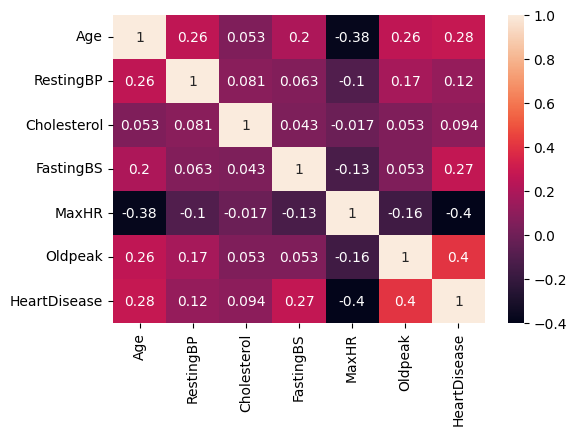

In [71]:
plt.figure(figsize=(6,4))
sns.heatmap(df_c.corr(numeric_only=True), annot=True)

# Data Preproses and Cleaning

In [72]:
X = df_c.drop('HeartDisease', axis=1)
y = df_c['HeartDisease']

In [73]:
y.head()

,HeartDisease
0,0
1,1
2,0
3,1
4,0


In [74]:
X.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up


# LabelEncoding


In [75]:
from sklearn.preprocessing import LabelEncoder
X_lable = X.copy()
label_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

le = LabelEncoder()

for col in label_cols:
    X_lable[col] = le.fit_transform(X_lable[col])


In [86]:
X_lable.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,40,1,1,140.0,289.0,0,1,172,0,0.0,2
1,49,0,2,160.0,180.0,0,1,156,0,1.0,1
2,37,1,1,130.0,283.0,0,2,98,0,0.0,2
3,48,0,0,138.0,214.0,0,1,108,1,1.5,1
4,54,1,2,150.0,195.0,0,1,122,0,0.0,2


In [87]:
X_lable.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope'],
      dtype='object')

In [91]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_lable[['Age','RestingBP','FastingBS','MaxHR','Oldpeak']] = scaler.fit_transform(X_lable[['Age','RestingBP','FastingBS','MaxHR','Oldpeak']])
X_lable.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
0,-1.433140,1,1,0.399696,289.0,-0.551341,1,1.382928,0,-0.832432,2
1,-0.478484,0,2,1.489232,180.0,-0.551341,1,0.754157,0,0.105664,1
2,-1.751359,1,1,-0.145072,283.0,-0.551341,2,-1.525138,0,-0.832432,2
3,-0.584556,0,0,0.290742,214.0,-0.551341,1,-1.132156,1,0.574711,1
4,0.051881,1,2,0.944464,195.0,-0.551341,1,-0.581981,0,-0.832432,2


# One-hot Encoding


In [105]:
X_encoded = pd.get_dummies(X, columns=['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'])
columns_to_convert = ['Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N',
       'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
X_encoded[columns_to_convert] = X_encoded[columns_to_convert].astype(int)
X_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_F,Sex_M,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,1,0,1,0,0,0,1,0,1,0,0,0,1
1,49,160.0,180.0,0,156,1.0,1,0,0,0,1,0,0,1,0,1,0,0,1,0
2,37,130.0,283.0,0,98,0.0,0,1,0,1,0,0,0,0,1,1,0,0,0,1
3,48,138.0,214.0,0,108,1.5,1,0,1,0,0,0,0,1,0,0,1,0,1,0
4,54,150.0,195.0,0,122,0.0,0,1,0,0,1,0,0,1,0,1,0,0,0,1


In [103]:
X_encoded.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH',
       'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N',
       'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

# ML model training


In [92]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_squared_error

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X_lable, y, test_size=0.20, random_state=42)

In [97]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [98]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1])

In [100]:
# Method A: Direct evaluation using .score()
test_accuracy = model.score(X_test, y_test)
print(f"Model Test Accuracy: {test_accuracy:.4f}")

# Method B: Using accuracy_score()
y_pred = model.predict(X_test)
score = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {score:.4f}")

Model Test Accuracy: 0.8478
Accuracy Score: 0.8478


ML Train One-hot Encoding

In [106]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, r2_score, mean_squared_error

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.20, random_state=42)

In [108]:
model1 = LogisticRegression()
model1.fit(X_train, y_train)

LogisticRegression()

In [110]:
y_pred1 = model1.predict(X_test)
y_pred1

array([0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1])

In [111]:
# Method A: Direct evaluation using .score()
test_accuracy1 = model1.score(X_test, y_test)
print(f"Model Test Accuracy: {test_accuracy1:.4f}")

# Method B: Using accuracy_score()
y_pred1 = model1.predict(X_test)
score1 = accuracy_score(y_test, y_pred1)
print(f"Accuracy Score: {score1:.4f}")

Model Test Accuracy: 0.8641
Accuracy Score: 0.8641


# **Conclusion**:
  Based on these results, the model trained
using One-Hot Encoding for the categorical features performed slightly better in predicting heart disease with an accuracy of 0.8641, compared to the Label Encoded model's accuracy of 0.8478. This suggests that representing categorical features as separate binary columns '**one-hot encoding**' was more effective for this particular dataset and logistic regression model than assigning a single numerical value '**label encoding**'.

# Accuracy Comparison:

    Model trained with Label Encoding: The test accuracy achieved was 0.8478.
    Model trained with One-Hot Encoding: The test accuracy achieved was 0.8641.